# Digital Twin Log Review — Notebook V1

This notebook combines the useful parts of the two current log-analysis scripts into one review flow.

## What this notebook is for

This is meant to help Barbara quickly answer questions like:

- How much real usage happened, after excluding owner traffic?
- What are people actually asking?
- Are there reliability problems, such as empty responses or malformed turns?
- How healthy does retrieval look?
- Which sessions were most engaged?
- What models, workflows, and providers are being exercised?
- Are votes, latency, and costs moving in a direction that feels good?

## Design principles

- One **config** section at the top
- Filters behave the same way as the scripts
- Operator-friendly review, not just a dump of tables
- Small number of dependable charts
- Easy to extend later into a dashboard


In [6]:
from pathlib import Path
import json
from collections import Counter, defaultdict
from datetime import datetime
from zoneinfo import ZoneInfo

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ----------------------------
# Config
# ----------------------------

LOG_PATH = Path("../latest.json")
CUTOFF_DATE = "2026-04-10"   # set to None to include all data
TIMEZONE = "America/Chicago"

# Owner traffic handling:
#   "none"    = keep all rows
#   "row"     = drop only owner-marked rows
#   "session" = drop any session containing owner-marked rows
OWNER_FILTER_MODE = "session"

COMPARE_OWNER_VIEWS = True
TOP_N = 15
RECENT_DAYS = 14


In [12]:
# ----------------------------
# Helpers
# ----------------------------

def parse_ts(ts_str: str) -> datetime:
    return datetime.fromisoformat(ts_str.replace("Z", "+00:00"))

def load_jsonl(path: Path):
    rows = []
    malformed_json = []
    with path.open("r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                malformed_json.append({
                    "line_num": line_num,
                    "reason": f"json_decode_error: {e}",
                    "raw": line[:300]
                })
    return rows, malformed_json

def local_dt(ts_str: str, timezone_str: str):
    tz = ZoneInfo(timezone_str)
    return parse_ts(ts_str).astimezone(tz)

def local_day(ts_str: str, timezone_str: str):
    return local_dt(ts_str, timezone_str).date().isoformat()

def apply_cutoff_df(df: pd.DataFrame, cutoff_date: str | None, timezone_str: str):
    if df.empty or not cutoff_date:
        return df.copy(), 0
    cutoff_dt = datetime.fromisoformat(f"{cutoff_date}T00:00:00").replace(tzinfo=ZoneInfo(timezone_str))
    keep_mask = df["local_ts"].isna() | (df["local_ts"] >= cutoff_dt)
    removed = int((~keep_mask).sum())
    return df.loc[keep_mask].copy(), removed

def owner_filter_frames(messages_df: pd.DataFrame, votes_df: pd.DataFrame, mode: str):
    if mode == "none":
        return messages_df.copy(), votes_df.copy(), {"removed_messages": 0, "removed_votes": 0, "removed_sessions": 0}
    if mode == "row":
        m = messages_df.loc[~messages_df["is_owner_traffic"].astype("boolean").fillna(False)].copy()
        v = votes_df.loc[~votes_df["is_owner_traffic"].fillna(False)].copy()
        return m, v, {
            "removed_messages": len(messages_df) - len(m),
            "removed_votes": len(votes_df) - len(v),
            "removed_sessions": 0,
        }
    if mode == "session":
        owner_sessions = set(messages_df.loc[messages_df["is_owner_traffic"].astype("boolean").fillna(False), "session_id"].dropna().astype(str))
        owner_sessions |= set(votes_df.loc[votes_df["is_owner_traffic"].astype("boolean").fillna(False), "session_id"].dropna().astype(str))

        m = messages_df.loc[
            ~messages_df["is_owner_traffic"].fillna(False)
            & ~messages_df["session_id"].astype(str).isin(owner_sessions)
        ].copy()

        v = votes_df.loc[
            ~votes_df["is_owner_traffic"].fillna(False)
            & ~votes_df["session_id"].astype(str).isin(owner_sessions)
        ].copy()

        return m, v, {
            "removed_messages": len(messages_df) - len(m),
            "removed_votes": len(votes_df) - len(v),
            "removed_sessions": len(owner_sessions),
        }
    raise ValueError(f"Unknown OWNER_FILTER_MODE: {mode}")

def safe_mean(series, ndigits=2):
    vals = pd.to_numeric(series, errors="coerce").dropna()
    if len(vals) == 0:
        return None
    return round(float(vals.mean()), ndigits)

def safe_median(series, ndigits=2):
    vals = pd.to_numeric(series, errors="coerce").dropna()
    if len(vals) == 0:
        return None
    return round(float(vals.median()), ndigits)

def pct(n, d):
    return round((100 * n / d), 1) if d else 0.0

def normalize_prompt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    x = text.lower().strip()
    x = " ".join(x.split())
    for ch in ['"', "'", "?", "!", ".", ",", ":", ";", "—", "-", "(", ")"]:
        x = x.replace(ch, "")
    x = " ".join(x.split())
    return x


In [13]:
# ----------------------------
# Load and classify rows
# ----------------------------

all_rows, malformed_json_rows = load_jsonl(LOG_PATH)
rows_df = pd.DataFrame(all_rows)

if rows_df.empty:
    raise ValueError(f"No rows loaded from {LOG_PATH}")

if "event" not in rows_df.columns:
    rows_df["event"] = None

rows_df["is_vote"] = rows_df["event"].eq("vote")
rows_df["ts"] = rows_df["ts"].where(rows_df["ts"].notna(), None)
rows_df["local_ts"] = rows_df["ts"].apply(lambda x: local_dt(x, TIMEZONE) if isinstance(x, str) else pd.NaT)

votes_df = rows_df.loc[rows_df["is_vote"]].copy()
messages_df_all = rows_df.loc[~rows_df["is_vote"]].copy()

messages_df_all["message_stripped"] = messages_df_all["message"].apply(lambda x: x.strip() if isinstance(x, str) else "")
artifact_mask = (
    messages_df_all["ts"].isna()
    | messages_df_all["message"].isna()
    | messages_df_all["message_stripped"].eq("")
)

empty_or_malformed_turns_df = messages_df_all.loc[artifact_mask].copy()
messages_df = messages_df_all.loc[~artifact_mask].copy()
messages_df = messages_df.loc[
    messages_df["session_id"].notna()
    & messages_df["turn_index"].notna()
].copy()

messages_df["session_id"] = messages_df["session_id"].astype(str)
votes_df["session_id"] = votes_df["session_id"].astype(str)
messages_df["normalized_prompt"] = messages_df["message"].apply(normalize_prompt)

print(f"All rows loaded: {len(rows_df)}")
print(f"Valid message rows: {len(messages_df)}")
print(f"Vote rows: {len(votes_df)}")
print(f"Empty/malformed turn artifacts: {len(empty_or_malformed_turns_df)}")
print(f"Malformed JSON rows: {len(malformed_json_rows)}")


All rows loaded: 238
Valid message rows: 139
Vote rows: 18
Empty/malformed turn artifacts: 0
Malformed JSON rows: 0


In [14]:
# ----------------------------
# Owner-view comparison (optional)
# ----------------------------

owner_view_metrics = []

if COMPARE_OWNER_VIEWS:
    for mode in ["none", "row", "session"]:
        m_tmp, v_tmp, owner_summary_tmp = owner_filter_frames(messages_df, votes_df, mode)
        m_tmp, cutoff_removed_m = apply_cutoff_df(m_tmp, CUTOFF_DATE, TIMEZONE)
        v_tmp, cutoff_removed_v = apply_cutoff_df(v_tmp, CUTOFF_DATE, TIMEZONE)

        session_counts = m_tmp.groupby("session_id").size()
        owner_view_metrics.append({
            "view": mode,
            "chat_turns": len(m_tmp),
            "sessions": int(m_tmp["session_id"].nunique()) if not m_tmp.empty else 0,
            "votes": len(v_tmp),
            "avg_turns_per_session": round(float(session_counts.mean()), 2) if len(session_counts) else 0,
            "avg_latency_ms": safe_mean(m_tmp["latency_ms"]),
            "avg_chunk_similarity": safe_mean(m_tmp["chunk_similarity_avg"], 3),
            "total_cost_usd": round(pd.to_numeric(m_tmp["cost_usd"], errors="coerce").fillna(0).sum(), 6),
            "owner_removed_messages": owner_summary_tmp["removed_messages"],
            "owner_removed_votes": owner_summary_tmp["removed_votes"],
            "owner_removed_sessions": owner_summary_tmp["removed_sessions"],
            "cutoff_removed_messages": cutoff_removed_m,
            "cutoff_removed_votes": cutoff_removed_v,
        })

owner_view_metrics_df = pd.DataFrame(owner_view_metrics)
owner_view_metrics_df


/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1042536530.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  v = votes_df.loc[~votes_df["is_owner_traffic"].fillna(False)].copy()
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1042536530.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~messages_df["is_owner_traffic"].fillna(False)
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1042536530.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change

,view,chat_turns,sessions,votes,avg_turns_per_session,avg_latency_ms,avg_chunk_similarity,total_cost_usd,owner_removed_messages,owner_removed_votes,owner_removed_sessions,cutoff_removed_messages,cutoff_removed_votes
0,none,112,48,17,2.33,4255.14,0.454,0.343378,0,0,0,27,1
1,row,105,46,14,2.28,4155.19,0.448,0.319957,7,3,0,27,1
2,session,104,45,14,2.31,4172.91,0.452,0.317138,8,3,3,27,1


In [15]:
# ----------------------------
# Apply final filters
# ----------------------------

messages_df_f, votes_df_f, owner_filter_summary = owner_filter_frames(messages_df, votes_df, OWNER_FILTER_MODE)
messages_df_f, cutoff_removed_messages = apply_cutoff_df(messages_df_f, CUTOFF_DATE, TIMEZONE)
votes_df_f, cutoff_removed_votes = apply_cutoff_df(votes_df_f, CUTOFF_DATE, TIMEZONE)

messages_df_f = messages_df_f.sort_values("local_ts").copy()
votes_df_f = votes_df_f.sort_values("local_ts").copy()

filter_summary = {
    "log_path": str(LOG_PATH),
    "timezone": TIMEZONE,
    "cutoff_date": CUTOFF_DATE,
    "owner_filter_mode": OWNER_FILTER_MODE,
    "messages_after_filters": len(messages_df_f),
    "votes_after_filters": len(votes_df_f),
    "owner_removed_messages": owner_filter_summary["removed_messages"],
    "owner_removed_votes": owner_filter_summary["removed_votes"],
    "owner_removed_sessions": owner_filter_summary["removed_sessions"],
    "cutoff_removed_messages": cutoff_removed_messages,
    "cutoff_removed_votes": cutoff_removed_votes,
    "empty_or_malformed_turn_artifacts": len(empty_or_malformed_turns_df),
    "malformed_json_rows": len(malformed_json_rows),
}

display(pd.DataFrame([filter_summary]))


/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1042536530.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~messages_df["is_owner_traffic"].fillna(False)
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1042536530.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~votes_df["is_owner_traffic"].fillna(False)


,log_path,timezone,cutoff_date,owner_filter_mode,messages_after_filters,votes_after_filters,owner_removed_messages,owner_removed_votes,owner_removed_sessions,cutoff_removed_messages,cutoff_removed_votes,empty_or_malformed_turn_artifacts,malformed_json_rows
0,../latest.json,America/Chicago,2026-04-10,session,104,14,8,3,3,27,1,0,0


## Overview


In [16]:
session_sizes = messages_df_f.groupby("session_id").size().rename("turns")
overview = {
    "chat_turns": len(messages_df_f),
    "sessions": int(messages_df_f["session_id"].nunique()) if not messages_df_f.empty else 0,
    "votes": len(votes_df_f),
    "avg_turns_per_session": round(float(session_sizes.mean()), 2) if len(session_sizes) else 0,
    "median_turns_per_session": round(float(session_sizes.median()), 2) if len(session_sizes) else 0,
    "one_turn_sessions": int((session_sizes == 1).sum()) if len(session_sizes) else 0,
    "pct_one_turn_sessions": pct(int((session_sizes == 1).sum()) if len(session_sizes) else 0, len(session_sizes)),
    "avg_latency_ms": safe_mean(messages_df_f["latency_ms"]),
    "avg_chunk_similarity": safe_mean(messages_df_f["chunk_similarity_avg"], 3),
    "avg_response_chars": safe_mean(messages_df_f["response_chars"]),
    "total_cost_usd": round(pd.to_numeric(messages_df_f["cost_usd"], errors="coerce").fillna(0).sum(), 6),
    "first_ts": messages_df_f["local_ts"].min(),
    "last_ts": messages_df_f["local_ts"].max(),
}
display(pd.DataFrame([overview]))


,chat_turns,sessions,votes,avg_turns_per_session,median_turns_per_session,one_turn_sessions,pct_one_turn_sessions,avg_latency_ms,avg_chunk_similarity,avg_response_chars,total_cost_usd,first_ts,last_ts
0,104,45,14,2.31,2.0,20,44.4,4172.91,0.452,1279.9,0.317138,2026-04-10 12:11:00.152502-05:00,2026-04-30 10:29:35.528869-05:00


,local_day,sessions,turns,votes
0,2026-04-10,19,38,0.0
1,2026-04-11,12,29,9.0
2,2026-04-12,1,1,0.0
3,2026-04-13,1,4,0.0
4,2026-04-14,3,13,0.0
5,2026-04-18,1,1,0.0
6,2026-04-19,1,3,0.0
7,2026-04-20,2,4,0.0
8,2026-04-21,1,5,2.0
9,2026-04-22,1,3,3.0


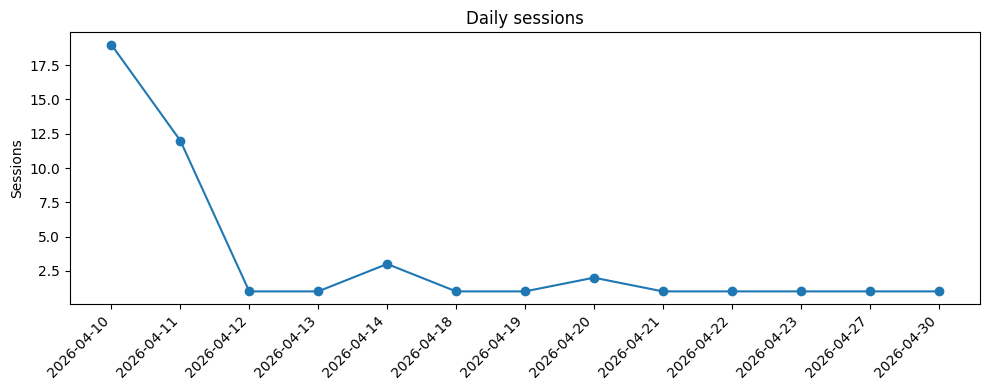

In [17]:
if not messages_df_f.empty:
    daily_turns = messages_df_f.assign(local_day=messages_df_f["local_ts"].dt.date.astype(str)).groupby("local_day").size().rename("turns")
    daily_sessions = (
        messages_df_f.groupby(["session_id"])
        .agg(start_local_ts=("local_ts", "min"))
        .assign(local_day=lambda d: d["start_local_ts"].dt.date.astype(str))
        .groupby("local_day")
        .size()
        .rename("sessions")
    )
    daily_votes = votes_df_f.assign(local_day=votes_df_f["local_ts"].dt.date.astype(str)).groupby("local_day").size().rename("votes") if not votes_df_f.empty else pd.Series(dtype=int)

    daily_df = pd.concat([daily_sessions, daily_turns, daily_votes], axis=1).fillna(0).reset_index().rename(columns={"index":"local_day"})
    daily_df = daily_df.sort_values("local_day")

    display(daily_df.tail(RECENT_DAYS))

    plt.figure(figsize=(10, 4))
    plt.plot(daily_df["local_day"], daily_df["sessions"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Sessions")
    plt.title("Daily sessions")
    plt.tight_layout()
    plt.show()


## Reliability and data quality


In [18]:
reliability = {
    "had_error_rows": int(messages_df_f["had_error"].fillna(False).sum()) if "had_error" in messages_df_f else 0,
    "empty_response_rows": int(messages_df_f["empty_response"].fillna(False).sum()) if "empty_response" in messages_df_f else 0,
    "zero_retrieval_rows": int((pd.to_numeric(messages_df_f["n_chunks_retrieved"], errors="coerce").fillna(0) == 0).sum()),
    "tool_called_rows": int(messages_df_f["tool_called"].fillna(False).sum()) if "tool_called" in messages_df_f else 0,
    "empty_or_malformed_turn_artifacts": len(empty_or_malformed_turns_df),
    "malformed_json_rows": len(malformed_json_rows),
}
display(pd.DataFrame([reliability]))


/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1357071772.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "had_error_rows": int(messages_df_f["had_error"].fillna(False).sum()) if "had_error" in messages_df_f else 0,
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1357071772.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "empty_response_rows": int(messages_df_f["empty_response"].fillna(False).sum()) if "empty_response" in messages_df_f else 0,
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1357

,had_error_rows,empty_response_rows,zero_retrieval_rows,tool_called_rows,empty_or_malformed_turn_artifacts,malformed_json_rows
0,0,0,0,2,0,0


In [19]:
problem_rows = messages_df_f.loc[
    messages_df_f["had_error"].fillna(False)
    | messages_df_f["empty_response"].fillna(False)
    | (pd.to_numeric(messages_df_f["n_chunks_retrieved"], errors="coerce").fillna(0) == 0)
].copy()

if not problem_rows.empty:
    cols = [c for c in [
        "local_ts", "session_id", "turn_index", "message", "had_error",
        "empty_response", "n_chunks_retrieved", "chunk_similarity_avg",
        "tool_called", "tool_name", "response_chars"
    ] if c in problem_rows.columns]
    display(problem_rows[cols].tail(20))
else:
    print("No reliability problem rows after current filters.")

if not empty_or_malformed_turns_df.empty:
    artifact_cols = [c for c in ["ts", "session_id", "turn_index", "message", "is_owner_traffic"] if c in empty_or_malformed_turns_df.columns]
    display(empty_or_malformed_turns_df[artifact_cols].tail(20))


No reliability problem rows after current filters.


/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/3791083476.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  messages_df_f["had_error"].fillna(False)
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/3791083476.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | messages_df_f["empty_response"].fillna(False)


## Prompt popularity


In [20]:
top_exact = (
    messages_df_f["message"]
    .value_counts()
    .rename_axis("prompt")
    .reset_index(name="count")
    .head(TOP_N)
)
top_normalized = (
    messages_df_f["normalized_prompt"]
    .value_counts()
    .rename_axis("normalized_prompt")
    .reset_index(name="count")
    .head(TOP_N)
)

display(Markdown("### Top exact prompts"))
display(top_exact)

display(Markdown("### Top normalized prompts"))
display(top_normalized)


### Top exact prompts

,prompt,count
0,What problems does Barbara solve?,16
1,How was this digital twin built?,10
2,What led you from cognitive science to AI engi...,5
3,Walk me through a project,4
4,Can you explain how RAG works in simple terms?,4
5,What's a project you built that you're really ...,3
6,What are you working on these days that's ligh...,3
7,What has been the most radical change in your ...,1
8,Who are you?,1
9,how many documents are in your database?,1


### Top normalized prompts

,normalized_prompt,count
0,what problems does barbara solve,16
1,how was this digital twin built,10
2,what led you from cognitive science to ai engi...,5
3,walk me through a project,4
4,can you explain how rag works in simple terms,4
5,what are you working on these days thats light...,3
6,whats a project you built that youre really pr...,3
7,who was her favorite roommate,2
8,what do you think of aude oliva,2
9,seems like youre saying only positive things a...,2


## Session behavior


In [21]:
session_df = (
    messages_df_f.groupby("session_id")
    .agg(
        start_local_ts=("local_ts", "min"),
        end_local_ts=("local_ts", "max"),
        turns=("turn_index", "count"),
        first_prompt=("message", "first"),
        last_prompt=("message", "last"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_similarity=("chunk_similarity_avg", "mean"),
        total_response_chars=("response_chars", "sum"),
        total_cost_usd=("cost_usd", "sum"),
        has_error=("had_error", "max"),
        has_empty_response=("empty_response", "max"),
    )
    .reset_index()
    .sort_values("start_local_ts")
)

display(session_df.sort_values(["turns", "start_local_ts"], ascending=[False, True]).head(TOP_N))


,session_id,start_local_ts,end_local_ts,turns,first_prompt,last_prompt,avg_latency_ms,avg_similarity,total_response_chars,total_cost_usd,has_error,has_empty_response
18,ddju23210xt,2026-04-14 16:37:09.546858-05:00,2026-04-14 16:41:57.494435-05:00,7,What problems does Barbara solve?,3 Marathons that's quite and achievment!,2965.714286,0.243143,4943.0,0.018115,False,NaN
33,kcqol37muog,2026-04-11 13:20:17.508594-05:00,2026-04-11 13:23:34.113750-05:00,5,Hey barbara twin,No you lost me,2695.800000,0.123600,2986.0,0.012584,False,NaN
12,arpwearlgfp,2026-04-11 16:45:15.056685-05:00,2026-04-11 16:49:43.345039-05:00,5,Who was her favorite roommate,No you lost me,2874.600000,0.151600,3273.0,0.012364,False,NaN
11,ao83f1gy049,2026-04-11 22:06:04.918576-05:00,2026-04-11 22:06:35.684882-05:00,5,"How did you get into beekeeping, and does it i...",What kinds of problems get you most excited to...,3100.600000,0.711200,8488.0,0.016036,False,NaN
31,kb88y9pemc,2026-04-14 04:07:58.719231-05:00,2026-04-14 04:15:17.691328-05:00,5,What has been the most radical change in your ...,how many documents are in your database?,5280.000000,0.194800,6386.0,0.014495,False,NaN
17,d5lbn00fz36,2026-04-21 11:56:18.960689-05:00,2026-04-21 12:01:15.403276-05:00,5,What problems does Barbara solve?,"That's great, it was nice chatting with you!",3309.400000,0.201200,4478.0,0.013964,False,NaN
19,dfp7fppdiwg,2026-04-10 15:16:34.427270-05:00,2026-04-10 15:17:21.340403-05:00,4,What problems does Barbara solve?,How was this digital twin build?,3044.500000,0.524250,5132.0,0.010913,False,NaN
2,22r4c07t98i,2026-04-13 01:57:07.616923-05:00,2026-04-13 01:58:45.024164-05:00,4,What is your experience with AI Engineering?,Mitja Bosnic\nJust testing your digital twin,3379.250000,0.468750,2736.0,0.009361,False,NaN
30,k3804gcxqk,2026-04-10 15:13:40.443641-05:00,2026-04-10 15:14:22.063104-05:00,3,What problems does Barbara solve?,Can you explain how RAG works in simple terms?,3739.000000,0.646000,3561.0,0.007887,False,NaN
29,jrz54qqmuqc,2026-04-10 15:19:10.184930-05:00,2026-04-10 15:19:44.845075-05:00,3,What problems does Barbara solve?,How was this digital twin built?,3819.666667,0.508333,4123.0,0.007970,False,NaN


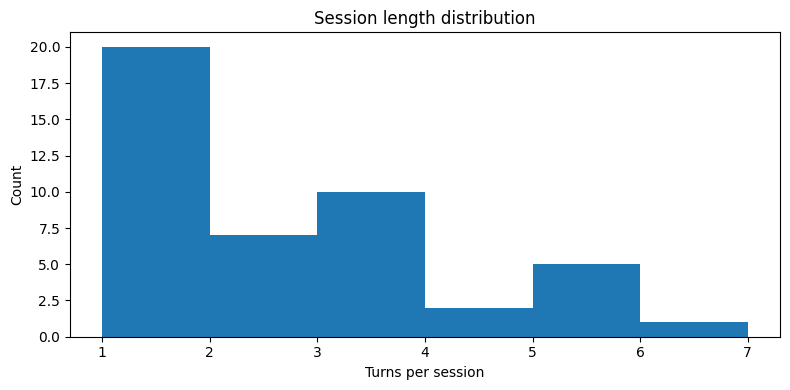

In [22]:
if not session_df.empty:
    plt.figure(figsize=(8, 4))
    plt.hist(session_df["turns"], bins=min(15, max(3, session_df["turns"].nunique())))
    plt.xlabel("Turns per session")
    plt.ylabel("Count")
    plt.title("Session length distribution")
    plt.tight_layout()
    plt.show()


## Retrieval health


In [23]:
retrieval_summary = {
    "avg_chunks_retrieved": safe_mean(messages_df_f["n_chunks_retrieved"]),
    "avg_similarity": safe_mean(messages_df_f["chunk_similarity_avg"], 3),
    "median_similarity": safe_median(messages_df_f["chunk_similarity_avg"], 3),
    "max_similarity": round(float(pd.to_numeric(messages_df_f["chunk_similarity_max"], errors="coerce").max()), 3) if not messages_df_f.empty else None,
    "zero_retrieval_rows": int((pd.to_numeric(messages_df_f["n_chunks_retrieved"], errors="coerce").fillna(0) == 0).sum()),
    "low_similarity_rows_lt_010": int((pd.to_numeric(messages_df_f["chunk_similarity_avg"], errors="coerce").fillna(0) < 0.10).sum()),
}
display(pd.DataFrame([retrieval_summary]))

display(Markdown("### Worst retrieval prompts"))
display(
    messages_df_f.sort_values("chunk_similarity_avg", ascending=True)[
        ["local_ts", "message", "chunk_similarity_avg", "chunk_similarity_max", "n_chunks_retrieved", "workflow"]
    ].head(TOP_N)
)

display(Markdown("### Best retrieval prompts"))
display(
    messages_df_f.sort_values("chunk_similarity_avg", ascending=False)[
        ["local_ts", "message", "chunk_similarity_avg", "chunk_similarity_max", "n_chunks_retrieved", "workflow"]
    ].head(TOP_N)
)


,avg_chunks_retrieved,avg_similarity,median_similarity,max_similarity,zero_retrieval_rows,low_similarity_rows_lt_010
0,4.06,0.452,0.601,0.937,0,22


### Worst retrieval prompts

,local_ts,message,chunk_similarity_avg,chunk_similarity_max,n_chunks_retrieved,workflow
203,2026-04-18 11:02:23.581759-05:00,Do you like kids,0.000,0.000,4.0,standard
162,2026-04-11 16:49:43.345039-05:00,No you lost me,0.000,0.000,4.0,standard
156,2026-04-11 13:23:34.113750-05:00,No you lost me,0.000,0.000,4.0,standard
150,2026-04-11 13:03:56.112532-05:00,"Try again, I think it was someone else",0.000,0.000,4.0,standard
216,2026-04-21 12:01:15.403276-05:00,"That's great, it was nice chatting with you!",0.000,0.000,4.0,standard
201,2026-04-14 16:40:55.959067-05:00,"Yes, i like hiking and cicling",0.000,0.000,4.0,standard
151,2026-04-11 13:04:28.300973-05:00,Yes please!,0.000,0.000,4.0,standard
121,2026-04-10 15:15:07.583371-05:00,Hi who are you,0.002,0.007,4.0,standard
200,2026-04-14 16:40:05.237481-05:00,So you like outdoors?,0.003,0.013,4.0,standard
213,2026-04-21 11:57:58.552799-05:00,can you summarize it further,0.004,0.009,4.0,standard


### Best retrieval prompts

,local_ts,message,chunk_similarity_avg,chunk_similarity_max,n_chunks_retrieved,workflow
210,2026-04-20 14:11:13.386550-05:00,What's something you're learning right now jus...,0.834,0.885,4.0,standard
173,2026-04-11 22:03:56.531376-05:00,What led you from cognitive science to AI engi...,0.814,0.880,4.0,standard
164,2026-04-11 20:37:04.780467-05:00,What led you from cognitive science to AI engi...,0.814,0.880,4.0,standard
169,2026-04-11 21:44:49.264598-05:00,What led you from cognitive science to AI engi...,0.814,0.880,4.0,standard
181,2026-04-11 22:06:19.562153-05:00,What led you from cognitive science to AI engi...,0.814,0.880,4.0,standard
171,2026-04-11 22:03:12.169676-05:00,What led you from cognitive science to AI engi...,0.814,0.880,4.0,standard
218,2026-04-22 07:48:35.933434-05:00,What does 'making meaning from messy data' act...,0.803,0.937,4.0,standard
179,2026-04-11 22:06:04.918576-05:00,"How did you get into beekeeping, and does it i...",0.770,0.887,4.0,diagram_only
170,2026-04-11 22:02:13.368585-05:00,How do you think about the connection between ...,0.764,0.868,4.0,standard
134,2026-04-10 15:25:02.475618-05:00,How was this digital twin built?,0.702,0.828,4.0,diagram_only


## Response size and latency outliers


In [24]:
display(Markdown("### Slowest rows"))
display(
    messages_df_f.sort_values("latency_ms", ascending=False)[
        ["local_ts", "message", "latency_ms", "response_chars", "workflow", "model"]
    ].head(TOP_N)
)

display(Markdown("### Largest responses"))
display(
    messages_df_f.sort_values("response_chars", ascending=False)[
        ["local_ts", "message", "response_chars", "latency_ms", "workflow", "project"]
    ].head(TOP_N)
)


### Slowest rows

,local_ts,message,latency_ms,response_chars,workflow,model
116,2026-04-10 15:12:27.030726-05:00,What problems does Barbara solve?,15780.0,1783.0,standard,openai/gpt-4.1
110,2026-04-10 12:49:15.876115-05:00,"Analyze this job description and give me the ""...",15260.0,5609.0,diagram_only,gemini/gemini-2.5-flash
109,2026-04-10 12:11:00.152502-05:00,Help me analyze this job description I got via...,12145.0,4473.0,standard,gemini/gemini-2.5-flash
111,2026-04-10 13:17:29.466945-05:00,Can you please help me with your experience wi...,9049.0,2752.0,standard,gemini/gemini-2.5-flash
203,2026-04-18 11:02:23.581759-05:00,Do you like kids,7875.0,286.0,standard,gemini/gemini-2.5-flash
236,2026-04-27 18:13:45.015457-05:00,How was this digital twin built?,6884.0,1785.0,diagram_only,gemini/gemini-2.5-flash
190,2026-04-14 04:07:58.719231-05:00,What has been the most radical change in your ...,6872.0,1393.0,standard,gemini/gemini-2.5-flash
115,2026-04-10 15:11:51.857494-05:00,What problems does Barbara solve?,6732.0,1618.0,standard,openai/gpt-4.1
195,2026-04-14 15:03:22.658661-05:00,Walk me through a project,6573.0,3206.0,walkthrough,gemini/gemini-2.5-flash
192,2026-04-14 04:10:02.658541-05:00,What was that first role in industry?,6389.0,1011.0,standard,gemini/gemini-2.5-flash


### Largest responses

,local_ts,message,response_chars,latency_ms,workflow,project
110,2026-04-10 12:49:15.876115-05:00,"Analyze this job description and give me the ""...",5609.0,15260.0,diagram_only,Poolula Platform
109,2026-04-10 12:11:00.152502-05:00,Help me analyze this job description I got via...,4473.0,12145.0,standard,None
206,2026-04-19 12:30:18.443698-05:00,tell me about your project with workouts and dog,3388.0,6083.0,walkthrough,Fitness Tracker
195,2026-04-14 15:03:22.658661-05:00,Walk me through a project,3206.0,6573.0,walkthrough,Concept Cartographer
147,2026-04-11 00:48:38.358457-05:00,Walk me through a project,2873.0,6371.0,walkthrough,ChronoScope
111,2026-04-10 13:17:29.466945-05:00,Can you please help me with your experience wi...,2752.0,9049.0,standard,None
112,2026-04-10 15:08:38.535648-05:00,Walk me through a project,2575.0,5789.0,walkthrough,Academic Citation Platform
114,2026-04-10 15:09:39.381727-05:00,How was this digital twin built?,2480.0,4961.0,diagram_only,Digital Twin
137,2026-04-10 15:30:14.394488-05:00,How was this digital twin built?,2101.0,3120.0,diagram_only,Digital Twin
131,2026-04-10 15:22:35.836538-05:00,How was this digital twin built?,2054.0,3482.0,diagram_only,Digital Twin


## Workflow, provider, and model mix


In [25]:
workflow_df = (
    messages_df_f.groupby("workflow")
    .agg(
        count=("workflow", "size"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_similarity=("chunk_similarity_avg", "mean"),
        avg_response_chars=("response_chars", "mean"),
        total_cost_usd=("cost_usd", "sum"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

provider_df = (
    messages_df_f.groupby("provider")
    .agg(
        count=("provider", "size"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_similarity=("chunk_similarity_avg", "mean"),
        total_cost_usd=("cost_usd", "sum"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

model_df = (
    messages_df_f.groupby("model")
    .agg(
        count=("model", "size"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_similarity=("chunk_similarity_avg", "mean"),
        avg_response_chars=("response_chars", "mean"),
        total_cost_usd=("cost_usd", "sum"),
        had_error_rows=("had_error", "sum"),
        empty_response_rows=("empty_response", "sum"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

display(Markdown("### Workflow"))
display(workflow_df)

display(Markdown("### Provider"))
display(provider_df)

display(Markdown("### Model"))
display(model_df)


### Workflow

,workflow,count,avg_latency_ms,avg_similarity,avg_response_chars,total_cost_usd
1,standard,81,4027.530864,0.395321,1046.703704,0.241904
0,diagram_only,14,4682.142857,0.687143,2065.571429,0.042187
2,walkthrough,9,4689.222222,0.594556,2156.555556,0.033046


### Provider

,provider,count,avg_latency_ms,avg_similarity,total_cost_usd
0,gemini,102,4034.029412,0.448392,0.285458
1,openai,2,11256.000000,0.628000,0.031680


### Model

,model,count,avg_latency_ms,avg_similarity,avg_response_chars,total_cost_usd,had_error_rows,empty_response_rows
0,gemini/gemini-2.5-flash,102,4034.029412,0.448392,1271.656863,0.285458,0,0
1,openai/gpt-4.1,2,11256.000000,0.628000,1700.500000,0.031680,0,0


## Vote review


In [26]:
if votes_df_f.empty:
    print("No votes after current filters.")
else:
    vote_summary = {
        "total_votes": len(votes_df_f),
        "likes": int(votes_df_f["liked"].eq(True).sum()),
        "dislikes": int(votes_df_f["liked"].eq(False).sum()),
        "other": int((~votes_df_f["liked"].isin([True, False])).sum()),
        "vote_rate_vs_messages_pct": pct(len(votes_df_f), len(messages_df_f)),
    }
    display(pd.DataFrame([vote_summary]))

    display(Markdown("### Recent vote rows"))
    vote_cols = [c for c in ["local_ts", "session_id", "liked", "user_message", "response_snippet", "model", "cost_usd"] if c in votes_df_f.columns]
    display(votes_df_f[vote_cols].tail(20))


,total_votes,likes,dislikes,other,vote_rate_vs_messages_pct
0,14,11,2,1,13.5


### Recent vote rows

,local_ts,session_id,liked,user_message,response_snippet,model,cost_usd
166,2026-04-11 20:42:20.752150-05:00,nan,True,[{'text': 'Can you explain how RAG works in si...,"['Absolutely! In simple terms, **RAG** (Retrie...",gemini/gemini-2.5-flash,0.002793
168,2026-04-11 21:44:37.613279-05:00,nan,True,"[{'text': 'Walk me through a project', 'type':...",['One project I\'m really excited to talk abou...,gemini/gemini-2.5-flash,0.003756
172,2026-04-11 22:03:27.271511-05:00,nan,True,[{'text': 'What led you from cognitive science...,"[""It's a great question, and honestly, it feel...",gemini/gemini-2.5-flash,0.002576
174,2026-04-11 22:04:06.088651-05:00,nan,,[{'text': 'What led you from cognitive science...,"[""It's a great question, and honestly, it feel...",gemini/gemini-2.5-flash,0.002495
175,2026-04-11 22:04:08.136443-05:00,nan,True,[{'text': 'What led you from cognitive science...,"[""It's a great question, and honestly, it feel...",gemini/gemini-2.5-flash,0.002495
176,2026-04-11 22:04:13.615383-05:00,nan,False,[{'text': 'What led you from cognitive science...,"[""It's funny, from the outside, it might look ...",gemini/gemini-2.5-flash,0.002495
177,2026-04-11 22:04:44.629078-05:00,nan,True,[{'text': 'What led you from cognitive science...,"[""It's funny, from the outside, it might look ...",gemini/gemini-2.5-flash,0.002495
178,2026-04-11 22:04:46.647494-05:00,nan,False,[{'text': 'What led you from cognitive science...,"[""It's funny, from the outside, it might look ...",gemini/gemini-2.5-flash,0.002495
184,2026-04-11 22:06:58.857106-05:00,nan,True,[{'text': 'What kinds of problems get you most...,['I get most excited by problems that look mes...,gemini/gemini-2.5-flash,0.003103
215,2026-04-21 12:01:12.041466-05:00,nan,True,"[{'text': 'tell me about your interests', 'typ...","[""I have a pretty wide range of interests, bot...",gemini/gemini-2.5-flash,0.002855


## Findings draft


In [27]:
def findings_markdown():
    lines = []
    lines.append("## Current readout")
    lines.append("")
    lines.append(f"- Messages after filters: **{len(messages_df_f)}** across **{messages_df_f['session_id'].nunique() if not messages_df_f.empty else 0}** sessions.")
    lines.append(f"- Owner filter mode: **{OWNER_FILTER_MODE}**. Cutoff date: **{CUTOFF_DATE or 'None'}** in **{TIMEZONE}**.")
    lines.append(f"- Empty/malformed turn artifacts tracked separately: **{len(empty_or_malformed_turns_df)}**.")
    lines.append(f"- Empty response rows after filters: **{int(messages_df_f['empty_response'].fillna(False).sum()) if 'empty_response' in messages_df_f else 0}**.")
    lines.append(f"- Had-error rows after filters: **{int(messages_df_f['had_error'].fillna(False).sum()) if 'had_error' in messages_df_f else 0}**.")
    lines.append(f"- Zero-retrieval rows after filters: **{int((pd.to_numeric(messages_df_f['n_chunks_retrieved'], errors='coerce').fillna(0) == 0).sum()) if not messages_df_f.empty else 0}**.")
    if not top_normalized.empty:
        top_row = top_normalized.iloc[0]
        lines.append(f"- Most repeated normalized prompt right now: **{top_row['normalized_prompt']}** ({top_row['count']}x).")
    lines.append("")
    lines.append("## Suggested next instrumentation questions")
    lines.append("")
    lines.append("- Do we want prompt/completion tokens to remain `null` for stream mode, or attempt a provider-specific recovery path later?")
    lines.append("- Do we want to surface notification success/failure as a first-class metric in the app log?")
    lines.append("- Do we want a session-quality score later that combines turns, votes, retrieval health, and reliability signals?")
    lines.append("- Do we want separate stakeholder views later: operator, product-owner, and portfolio-story views?")
    return "\n".join(lines)

display(Markdown(findings_markdown()))


/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1508963944.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lines.append(f"- Empty response rows after filters: **{int(messages_df_f['empty_response'].fillna(False).sum()) if 'empty_response' in messages_df_f else 0}**.")
/var/folders/nj/c5gpw01138j8pfc0j___w2qm0000gn/T/ipykernel_56132/1508963944.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lines.append(f"- Had-error rows after filters: **{int(messages_df_f['had_error'].fillna(False).sum()) if 'had_error' in messages_df_f else 0}*

## Current readout

- Messages after filters: **104** across **45** sessions.
- Owner filter mode: **session**. Cutoff date: **2026-04-10** in **America/Chicago**.
- Empty/malformed turn artifacts tracked separately: **0**.
- Empty response rows after filters: **0**.
- Had-error rows after filters: **0**.
- Zero-retrieval rows after filters: **0**.
- Most repeated normalized prompt right now: **what problems does barbara solve** (16x).

## Suggested next instrumentation questions

- Do we want prompt/completion tokens to remain `null` for stream mode, or attempt a provider-specific recovery path later?
- Do we want to surface notification success/failure as a first-class metric in the app log?
- Do we want a session-quality score later that combines turns, votes, retrieval health, and reliability signals?
- Do we want separate stakeholder views later: operator, product-owner, and portfolio-story views?